# Titanic challenge part 2
In this kernel, we will be covering all of the steps required to train, tune and assess a random forest model. 

[**Part 1**](https://www.kaggle.com/jamesleslie/titanic-eda-wrangling-imputation/notebook) of this series dealt with the pre-processing and manipulation of the data. This notebook will make use of the data sets that were created in the first part.   

We will do each of the following:
  - train and test default RF model
  - introduce cross-validation for model training
  - use grid search to optimize hyperparameters
  - submit our predictions for the test set
  
[**Part 3**](https://www.kaggle.com/jamesleslie/titanic-neural-network-for-beginners/notebook) of this challenge involves fitting and tuning a **neural network** to make predictions.

# Table of Contents:

- **1. [Load packages and data](#loading)**
- **2. [Pre-processing](#pre-processing)**
- **3. [Random Forest](#random-forest)**
  - **3.1. [Train/test split](#train-test)**
  - **3.2. [Cross-validation](#cv)**
  - **3.3. [Grid search](#grid-search)**
- **4. [Submit predictions](#submission)**

<a id="loading"></a>
# 1. Load packages and data
We will be using the train and test sets that we created in [part 1](https://www.kaggle.com/jamesleslie/titanic-eda-wrangling-imputation/notebook) of this series.   

You can find the dataset [here](https://www.kaggle.com/jamesleslie/titanic-cleaned-data).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import rcParams
import os
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

%matplotlib inline
rcParams['figure.figsize'] = 10,8
sns.set(style='whitegrid', palette='muted',
        rc={'figure.figsize': (15,10)})

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
# print(os.listdir("../input"))

C:\Users\aby\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
print(os.listdir("."))

['.opera', '13.5.1 Packet Tracer - WLAN Configuration.pka', '1769341933-28839-ae3aa6ae-3f27-4086-bb18-e4330fa00379.zip', 'abbynaila26.ovpn', 'Abigael_CV.pdf', 'Abigael_Nailantei_Saruni_CV.docx', 'Abigael_Nailantei_Saruni_Skills_Based_CV.pdf', 'Abigael_Saruni_CV_Kenya_Format.docx', 'Additional_download-3901.zip', 'Anaconda3-2025.06-0-Windows-x86_64.exe', 'AnyDesk.exe', 'Application Form.docx.pdf', 'ArduinoUNOLibraryforProteus.zip', 'Asphalt 8_ Airborne Installer.exe', 'Assignment 2 AWS Cloud Account Registration Completion requirements.pdf', 'Assignment-1-Configuring ASA firewall.pka', 'Auditor_report.zip', 'AUGUST RECEIPT ALX.pdf', 'az-500-10_azuredeploy.json', 'az500-lab10-all-resources', 'bagging_heart_disease_prediction.ipynb', 'Binary_classification_metrics_exercise.ipynb', 'Buttons', 'Buttons.zip', 'CASLSetup.exe', 'Classification_exercise.ipynb', 'Classification_hyperparameter_tuning_code_challenge_student_version.ipynb', 'climate_health_starter_notebook_.ipynb', 'cloudgoat-admin

In [17]:
# Load data as Pandas dataframe
train = pd.read_csv('C:\\Users\\aby\\OneDrive\\Desktop\\ZINDI_PROJECTS 2026\\Titanic_prediction\\train.csv')
test = pd.read_csv('C:\\Users\\aby\\OneDrive\\Desktop\\ZINDI_PROJECTS 2026\\Titanic_prediction\\test.csv')
df = pd.concat([train, test], axis=0, sort=True).reset_index(drop=True)

In [18]:
df.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450


In [19]:
def display_all(df):
    with pd.option_context("display.max_rows", 1000, "display.max_columns", 1000): 
        display(df)

        
display_all(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1046.0,NaN,NaN,NaN,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
Cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Embarked,1307,3,S,914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
Name,1309,1307,"Connolly, Miss. Kate",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
PassengerId,1309.0,NaN,NaN,NaN,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0
Pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0


In [20]:
df['Survived'].value_counts()

Survived
0.0    549
1.0    342
Name: count, dtype: int64

In [21]:
# Extract Title from Name (the link from Challenge 1)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                    'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

<a id="pre-processing"></a>
# 2. Encode categorical variables
We need to convert all categorical variables into numeric format. The categorical variables we will be keeping are `Embarked`, `Sex` and `Title`.   

The `Sex` variable can be encoded into single 1-or-0 column, but the other variables will need to be [one-hot encoded](https://hackernoon.com/what-is-one-hot-encoding-why-and-when-do-you-have-to-use-it-e3c6186d008f). Regular label encoding assigns some category labels higher numerical values. This implies some sort of scale (Embarked = 1 is not **more** than Embarked = 0 - it's just _different_). One Hot Encoding avoids this problem.   

We will assume that there is some ordinality in the `Pclass` variable, so we will leave that as a single column.

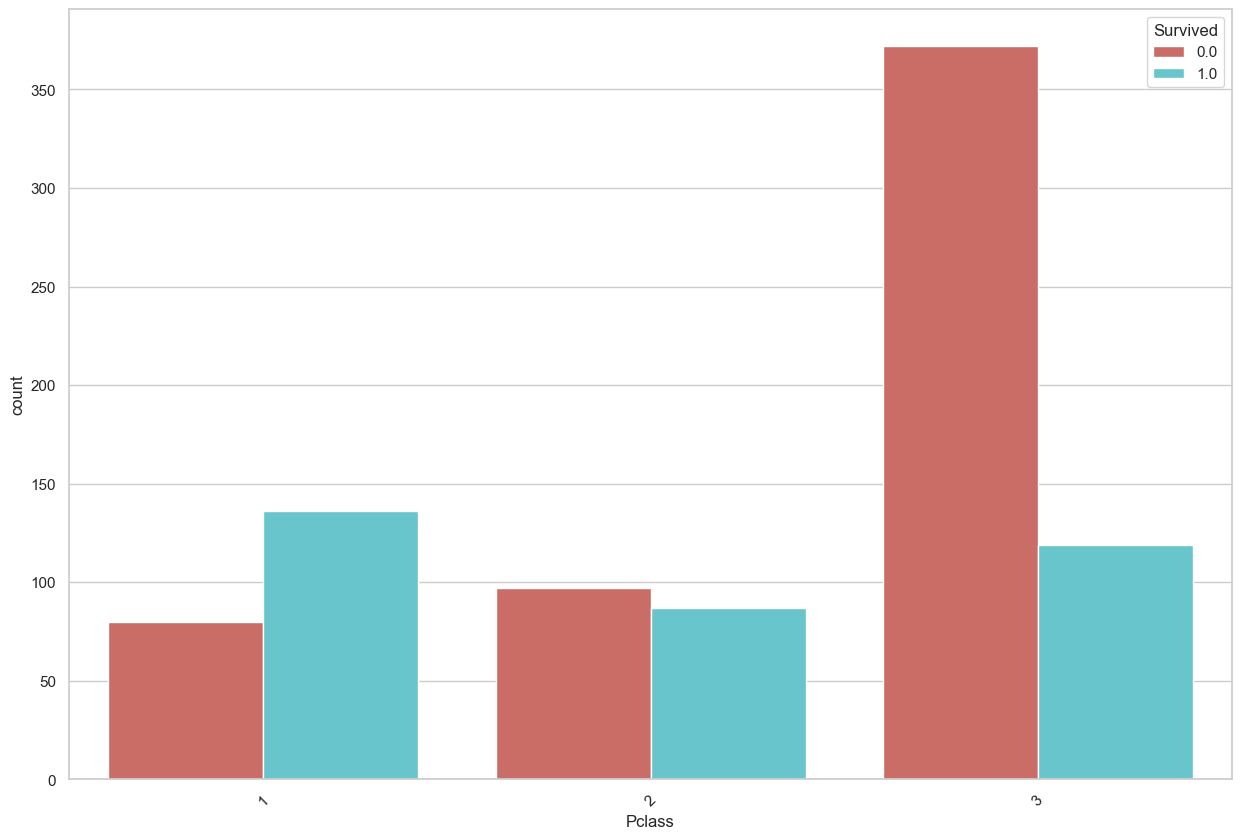

In [22]:
sns.countplot(x='Pclass', data=df, palette='hls', hue='Survived')
plt.xticks(rotation=45)
plt.show()

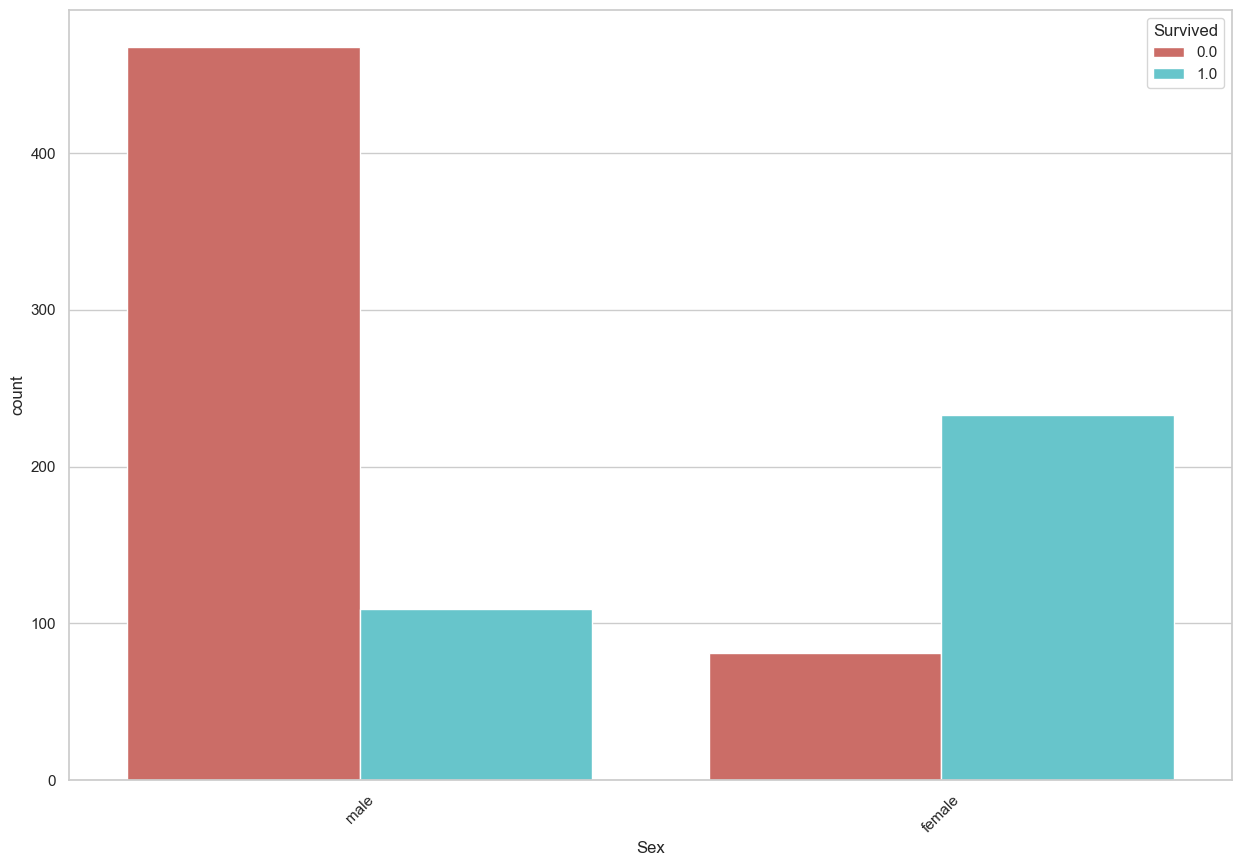

In [23]:
sns.countplot(x='Sex', data=df, palette='hls', hue='Survived')
plt.xticks(rotation=45)
plt.show()

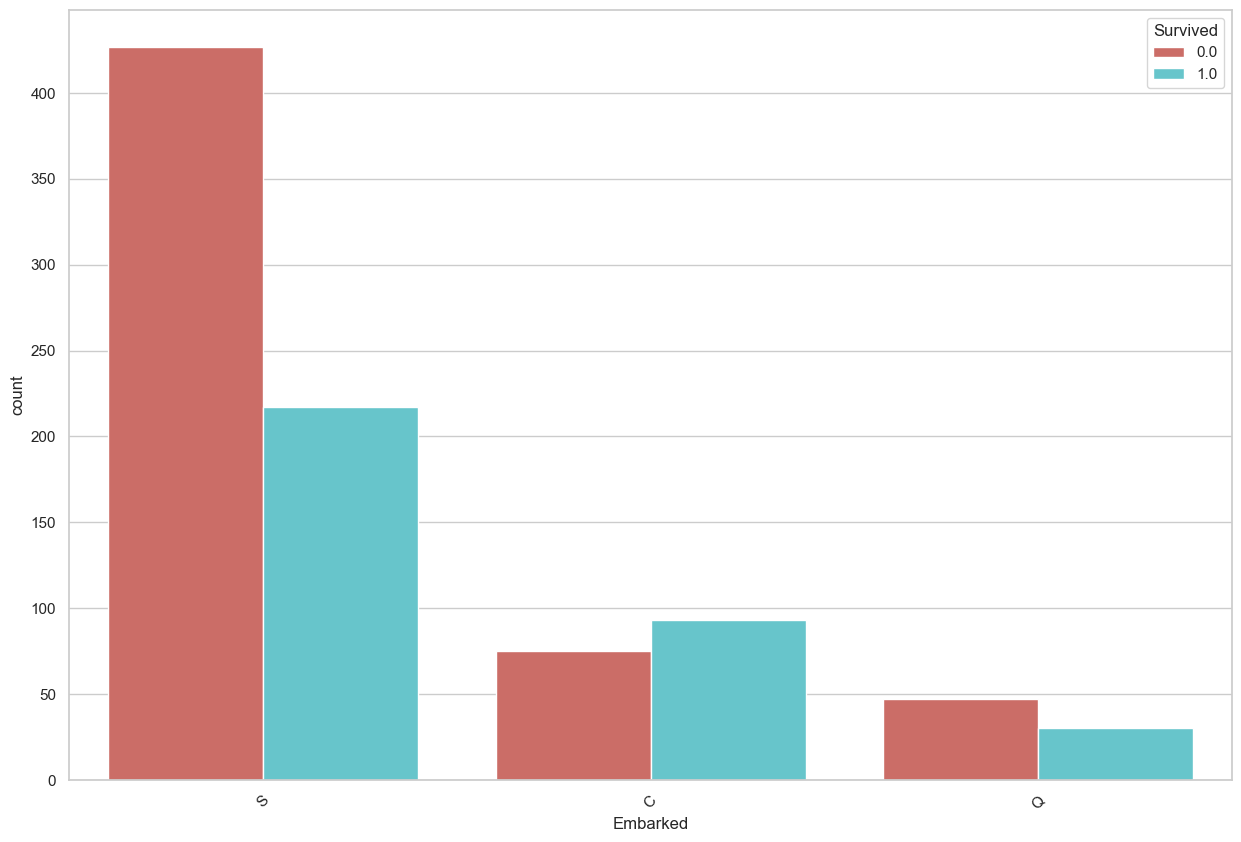

In [24]:
sns.countplot(x='Embarked', data=df, palette='hls', hue='Survived')
plt.xticks(rotation=45)
plt.show()

In [25]:
# convert to category dtype
df['Sex'] = df['Sex'].astype('category')
# convert to category codes
df['Sex'] = df['Sex'].cat.codes

In [26]:
# subset all categorical variables which need to be encoded
categorical = ['Embarked', 'Title']

for var in categorical:
    df = pd.concat([df, 
                    pd.get_dummies(df[var], prefix=var)], axis=1)
    del df[var]

In [27]:
# drop the variables we won't be using
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [28]:
df.head()

,Age,Fare,Parch,Pclass,Sex,SibSp,Survived,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,22.0,7.2500,0,3,1,1,0.0,False,False,True,False,False,True,False,False
1,38.0,71.2833,0,1,0,1,1.0,True,False,False,False,False,False,True,False
2,26.0,7.9250,0,3,0,0,1.0,False,False,True,False,True,False,False,False
3,35.0,53.1000,0,1,0,1,1.0,False,False,True,False,False,False,True,False
4,35.0,8.0500,0,3,1,0,0.0,False,False,True,False,False,True,False,False


<a id="random-forest"></a>
# 3. Random Forest
Now, all that is left is to feed our data that has been cleaned, encoded and scaled to a random forest.    
<a id="train-test"></a>
## 3.1. Train/test split
But first, we need to separate *data_df* back into *train* and *test* sets.

In [29]:
train = df[pd.notnull(df['Survived'])]
X_test = df[pd.isnull(df['Survived'])].drop(['Survived'], axis=1)

### Validation set
Since we can't use our test set to assess our model (it doesn't have any labels), we will create a separte 'validation set'. We will use this set to test how our model generalises to unseen data.

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(['Survived'], axis=1),
    train['Survived'],
    test_size=0.2, random_state=42)

In [31]:
for i in [X_train, X_val, X_test]:
    print(i.shape)

(712, 14)
(179, 14)
(418, 14)


### Create Random Forest model
We will first make a random forest model, using all of the default parameters.   
> Note: set the `random_state` to 42 for reproducibility

In [32]:
rf = RandomForestClassifier(random_state=42)

### Train model
Now, let's train the model on our training set.

In [33]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Test model

In [34]:
accuracy_score(y_val, rf.predict(X_val))

0.8379888268156425

<a id="cv"></a>
## 3.2. Cross-validation
Keeping a separate validation set means that we have less data on which to train our model. Cross-validation allows us to train our model on _all_ of the data, while still assessing its performance on unseen data.

K-folds cross validation is the process of creating *k* different train/validate splits in the data and training the model *k* times.

![CV](https://upload.wikimedia.org/wikipedia/commons/1/1c/K-fold_cross_validation_EN.jpg)   

In the image above, k=4. This means that the model will be trained 4 times, each time using 1/4 of the data for validation. In this way, each of the four 'folds' takes one turn sitting out from training and is used as the validation set.   

Let's combine our train and validation sets back into one training set, and then use cross-validation to assess our model:

In [35]:
X_train = pd.concat([X_train, X_val])
y_train = pd.concat([y_train, y_val])

In [36]:
X_train.shape

(891, 14)

Now we have all of training data again. Let's fit a model to it, and assess its accuracy using 5-fold cross-validation:

In [37]:
rf = RandomForestClassifier(n_estimators=10, random_state=42)
cross_val_score(rf, X_train, y_train, cv=5)

array([0.81005587, 0.84269663, 0.80337079, 0.83707865, 0.81460674])

In [38]:
cross_val_score(rf, X_train, y_train, cv=5).mean()

np.float64(0.8215617349821104)

Here, our CV score is slightly lower than our previous single validation score. Taking a look at the scores for each of the folds, the score does seem to vary slightly.   

Cross-validation has the added advantage of being a more robust measure of model accuracy than single validation.   
> Note: the method we used initially is actually just 1-fold cross-validation

<a id="grid-search"></a>
## 3.3. Hyperparameter tuning
Our first model didn't do too badly! It scored over 80% on the CV score. However, we didn't put any thought into our choice of hyperparameters, we simply went with the defaults.   

Take a look at the various parameters by using the `help()` function:

In [44]:
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

It is hard to know the best values for each of these hyperparameters without first _trying_ them out. If we wanted to know the best value for the `n_estimators` parameter, we could fit a few models, each with a different value, and see which one tests the best.   

**Grid search** allows us to do this for multiple parameters simultaneously. We will select a few different parameters that we want to tune, and for each one we will provide a few different values to try out. Then grid search will fit models to every possible combination of these parameter values and use **cross-validation** to assess the performance in each case.   

Furthermore, since we are using CV, we don't need to keep a separate validation set.

### 3.2.1. Number of estimators and max depth
We will start by tuning the `n_estimators` (number of trees in the forest) and the `max_depth` (how deep each tree grows) parameters.   

The first step that we need to do is to define the grid of parameters over which to search:

In [45]:
# create the grid
n_estimators = [10, 100, 1000, 2000]
max_depth = [None, 5, 10, 20]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth)

We have set out a total of $4 \times 4 = 16$ models over which to search. Grid search uses cross-validation on each of the models, so if we use 3-folds cross-validation, that will leave us with 48 different fits to try out. (You can see how the number of fits can grow pretty quickly as we increase the number of parameters!)   

The good news is that SkLearn's grid search allows us to run the job in parallel. Including the `n_jobs=-1` argument below let's grid search run on all of the available cores on the host machine.

In [46]:
# create the default model
rf = RandomForestClassifier(random_state=42)

# search the grid
grid = GridSearchCV(estimator=rf, 
                    param_grid=param_grid,
                    cv=3,
                    verbose=2,
                    n_jobs=-1)

grid_result = grid.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


Now let's take a look at the results of the grid search.   

We can get the best performing model directly from `grid_result`:

In [47]:
grid_result.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Or just the best parameters:

In [48]:
grid_result.best_params_

{'max_depth': 5, 'n_estimators': 1000}

Or the best score:

In [49]:
grid_result.best_score_

np.float64(0.8327721661054994)

But let's take a look at all of the models so we can make a more informed decision

In [50]:
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.832772 using {'max_depth': 5, 'n_estimators': 1000}
0.793490 (0.019309) with: {'max_depth': None, 'n_estimators': 10}
0.815937 (0.026417) with: {'max_depth': None, 'n_estimators': 100}
0.811448 (0.015307) with: {'max_depth': None, 'n_estimators': 1000}
0.813692 (0.018305) with: {'max_depth': None, 'n_estimators': 2000}
0.812570 (0.008837) with: {'max_depth': 5, 'n_estimators': 10}
0.831650 (0.015307) with: {'max_depth': 5, 'n_estimators': 100}
0.832772 (0.015632) with: {'max_depth': 5, 'n_estimators': 1000}
0.830527 (0.015141) with: {'max_depth': 5, 'n_estimators': 2000}
0.804714 (0.019244) with: {'max_depth': 10, 'n_estimators': 10}
0.827160 (0.018713) with: {'max_depth': 10, 'n_estimators': 100}
0.827160 (0.023381) with: {'max_depth': 10, 'n_estimators': 1000}
0.827160 (0.021354) with: {'max_depth': 10, 'n_estimators': 2000}
0.793490 (0.019309) with: {'max_depth': 20, 'n_estimators': 10}
0.817059 (0.022221) with: {'max_depth': 20, 'n_estimators': 100}
0.812570 (0.015141) with

We have just accomplished hyperparameter tuning and discovered our best from what we are working with.

### 3.2.2. Leaf size
The `min_samples_leaf` argument controls the size of the leaves in the trees.   

We will set out the grid in a similar manner as before, only this time we will use the `max_depth` and `n_estimators` parameters that we found above.

In [51]:
# create the grid
leaf_samples = [1, 2, 3, 4, 5, 6]
param_grid = dict(min_samples_leaf=leaf_samples)

# create the model with new max_depth and n_estimators
rf = grid_result.best_estimator_

# search the grid
grid = GridSearchCV(estimator=rf, 
                    param_grid=param_grid,
                    cv=3,
                    verbose=2,
                    n_jobs=-1)

grid_result = grid.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


In [52]:
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.832772 using {'min_samples_leaf': 1}
0.832772 (0.015632) with: {'min_samples_leaf': 1}
0.830527 (0.016798) with: {'min_samples_leaf': 2}
0.832772 (0.018305) with: {'min_samples_leaf': 3}
0.831650 (0.018027) with: {'min_samples_leaf': 4}
0.828283 (0.018027) with: {'min_samples_leaf': 5}
0.824916 (0.017168) with: {'min_samples_leaf': 6}


### 3.2.3. To bag or not to bag
Bootstrap aggregating (or bagging) is a special case of the random forest where we bootstrap (sample with replacement) from the n training obersvations to create a new training set of size n for each tree. Furthermore, each tree considers all variables when making each split.   

We can use grid search to determine if bootstrapping will be an appropriate method to use.

In [53]:
# create the grid
max_features = [5, 8, 10, 12, None]
bootstrap = [True, False]
param_grid = dict(max_features=max_features, bootstrap=bootstrap)

# create the model with new leaf size
rf = grid_result.best_estimator_

# search the grid
grid = GridSearchCV(estimator=rf, 
                    param_grid=param_grid,
                    cv=3,
                    verbose=2,
                    n_jobs=-1)

grid_result = grid.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [54]:
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.832772 using {'bootstrap': True, 'max_features': 10}
0.826038 (0.022050) with: {'bootstrap': True, 'max_features': 5}
0.827160 (0.017887) with: {'bootstrap': True, 'max_features': 8}
0.832772 (0.015141) with: {'bootstrap': True, 'max_features': 10}
0.826038 (0.014108) with: {'bootstrap': True, 'max_features': 12}
0.829405 (0.014108) with: {'bootstrap': True, 'max_features': None}
0.829405 (0.015141) with: {'bootstrap': False, 'max_features': 5}
0.827160 (0.015141) with: {'bootstrap': False, 'max_features': 8}
0.826038 (0.015141) with: {'bootstrap': False, 'max_features': 10}
0.819304 (0.014108) with: {'bootstrap': False, 'max_features': 12}
0.815937 (0.017887) with: {'bootstrap': False, 'max_features': None}


#bootstrapping allows every tree to be trained on slightly different data effectively reducing overfitting. In RandomForest, the collective agreement of these slightly trained trees is more trustworthy

<a id="submission"></a>
## 4. Make Predictions on Test Set
Finally, we can attempt to predict which passengers in the test set survived.

In [55]:
rf = grid_result.best_estimator_

In [56]:
# test our CV score
cross_val_score(rf, X_train, y_train, cv=5).mean()

np.float64(0.8327914129684263)

In [57]:
test['Survived'] = rf.predict(X_test)

In [58]:
solution = test[['PassengerId', 'Survived']]
solution['Survived'] = solution['Survived'].apply(int)

In [59]:
solution.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


## Output Final Predictions

In [60]:
solution.to_csv("Random_Forest_Solution.csv", index=False)